# Avance 4 · Análisis exploratorio complementario

La Fase A evaluada en el PDF corresponde al diseño de la bodega. Este notebook conserva el EDA pedido en el avance 4.

> **Alcance:** análisis del archivo recibido. Todas sus fechas tienen día entre 1 y 12; no se conoce su cobertura completa ni se ha confirmado el CSV oficial. Se conservan filas idénticas por falta de un identificador de evento. `CANTIDAD` se suma; no equivale necesariamente al número de filas.

In [1]:
from pathlib import Path
import sys
RAIZ = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/proyecto.py').is_file()), None)
if RAIZ is None:
    raise RuntimeError('Abra el notebook desde la carpeta del proyecto o entrega/.')
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
import pandas as pd
from IPython.display import display, Markdown
get_ipython().run_line_magic('matplotlib', 'inline')
from src.proyecto import extraer, transformar, conectar, cargar, consultar

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
fuente, huella = extraer()
_, datos, auditoria = transformar(fuente, huella)

## Clasificación de las 11 variables
No hay variables ordinales ni continuas en las columnas originales. Los códigos geográficos son identificadores nominales, aunque Excel los haya almacenado como números.

In [2]:
clasificacion = pd.DataFrame([
('FECHA HECHO','Temporal','Fecha de calendario; orden temporal, no magnitud continua'),
('COD_DEPTO','Nominal','Identificador geográfico'),('DEPARTAMENTO','Nominal','Categoría geográfica'),
('COD_MUNI','Nominal','Identificador geográfico'),('MUNICIPIO','Nominal','Categoría geográfica'),
('ZONA','Nominal','Categoría territorial'),('SEXO','Nominal','Categoría registrada'),
('ARMA MEDIO','Nominal','Medio registrado'),('MODALIDAD PRESUNTA','Nominal','Clasificación presunta'),
('SPOA_CARACTERIZACION','Nominal','Clasificación registrada'),('CANTIDAD','Cuantitativa discreta','Conteo por fila')
],columns=['variable','tipo','justificacion'])
display(clasificacion)

,variable,tipo,justificacion
0,FECHA HECHO,Temporal,"Fecha de calendario; orden temporal, no magnit..."
1,COD_DEPTO,Nominal,Identificador geográfico
2,DEPARTAMENTO,Nominal,Categoría geográfica
3,COD_MUNI,Nominal,Identificador geográfico
4,MUNICIPIO,Nominal,Categoría geográfica
5,ZONA,Nominal,Categoría territorial
6,SEXO,Nominal,Categoría registrada
7,ARMA MEDIO,Nominal,Medio registrado
8,MODALIDAD PRESUNTA,Nominal,Clasificación presunta
9,SPOA_CARACTERIZACION,Nominal,Clasificación registrada


## Descriptivos y outliers
Se calculan media, desviación estándar muestral, mínimo, máximo e IQR para CANTIDAD, la única magnitud numérica original. Año y códigos no se interpretan como medidas.

In [3]:
resumen=datos[['cantidad']].describe().T
resumen['IQR']=resumen['75%']-resumen['25%']
display(resumen)
q1,q3=datos.cantidad.quantile([.25,.75]); iqr=q3-q1
atipicos=(datos.cantidad<q1-1.5*iqr)|(datos.cantidad>q3+1.5*iqr)
display(datos.loc[atipicos,['fecha','municipio','cantidad']].head(10))
display(Markdown(f'**Conclusión:** IQR={iqr:.0f}; {atipicos.sum()} filas quedan fuera de la regla IQR. Al ser una variable casi constante, esta regla marca cantidades mayores que 1; no demuestra errores ni justifica eliminarlas.'))

,count,mean,std,min,25%,50%,75%,max,IQR
cantidad,31708.0,1.001198,0.036376,1.0,1.0,1.0,1.0,3.0,0.0


,fecha,municipio,cantidad
148,2025-08-12,SANTO DOMINGO,2
570,2025-10-11,PALMIRA,2
825,2025-03-11,CORINTO,2
1300,2025-03-10,BARRANQUILLA,2
1638,2025-06-09,CIENAGA,2
1867,2025-12-08,BUENAVENTURA,2
2140,2025-04-08,CHITA,2
2681,2025-02-07,CARTAGENA DE INDIAS,2
2697,2025-02-07,RIOHACHA,3
2812,2025-10-06,OCAÑA,2


**Conclusión:** IQR=0; 36 filas quedan fuera de la regla IQR. Al ser una variable casi constante, esta regla marca cantidades mayores que 1; no demuestra errores ni justifica eliminarlas.

## 1. Histograma con KDE
Se usa la cantidad agregada por mes, una variable derivada con más variación que CANTIDAD por fila. La KDE es una aproximación descriptiva sobre conteos.

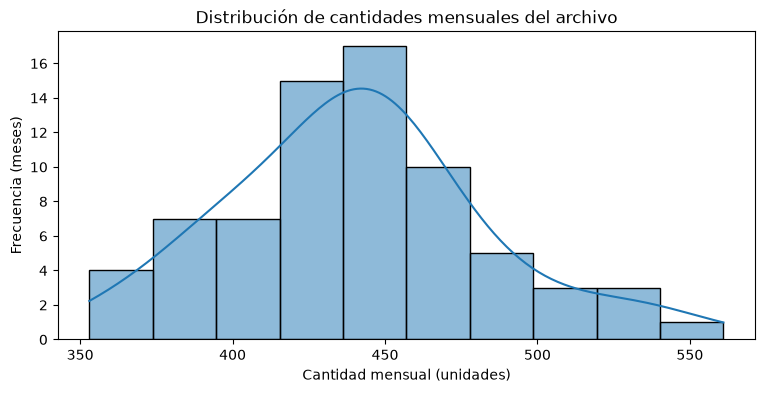

**Conclusión:** la asimetría muestral es 0.403 y la mediana es 442.0 unidades. La distribución mensual depende de la cobertura anómala de fechas.

In [4]:
mensual=datos.groupby(['anio','mes']).cantidad.sum().reset_index()
fig,ax=plt.subplots(figsize=(9,4)); sns.histplot(mensual.cantidad,kde=True,ax=ax)
ax.set(title='Distribución de cantidades mensuales del archivo',xlabel='Cantidad mensual (unidades)',ylabel='Frecuencia (meses)'); plt.show()
display(Markdown(f'**Conclusión:** la asimetría muestral es {mensual.cantidad.skew():.3f} y la mediana es {mensual.cantidad.median():.1f} unidades. La distribución mensual depende de la cobertura anómala de fechas.'))

## 2. Boxplot comparativo
La unidad de análisis es mes-zona; no cada fila.

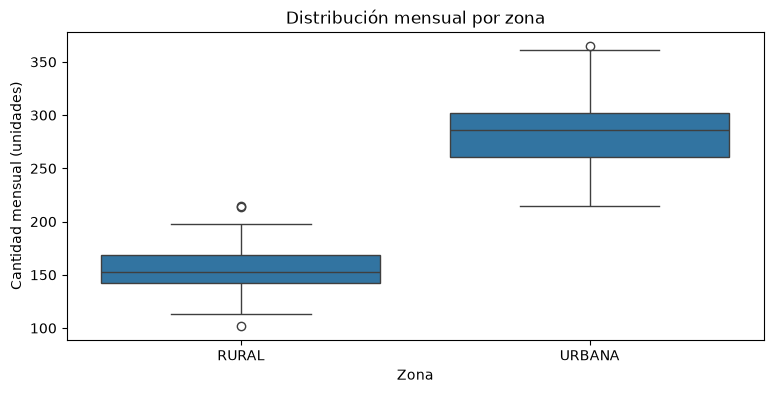

**Conclusión:** URBANA presenta la mayor mediana mensual, 286.5 unidades. La diferencia describe cantidades absolutas; falta población para comparar tasas.

In [5]:
zona=datos.groupby(['anio','mes','zona']).cantidad.sum().reset_index()
fig,ax=plt.subplots(figsize=(9,4)); sns.boxplot(data=zona,x='zona',y='cantidad',ax=ax)
ax.set(title='Distribución mensual por zona',xlabel='Zona',ylabel='Cantidad mensual (unidades)'); plt.show()
med=zona.groupby('zona').cantidad.median().sort_values(ascending=False)
display(Markdown(f'**Conclusión:** {med.index[0]} presenta la mayor mediana mensual, {med.iloc[0]:.1f} unidades. La diferencia describe cantidades absolutas; falta población para comparar tasas.'))

## 3. Heatmap de correlación
Solo hay una magnitud numérica original. Para evitar correlacionar códigos nominales, se correlacionan dos medidas derivadas: cantidades urbanas y rurales de cada mes. Se excluye el total para no introducir una relación parte-todo.

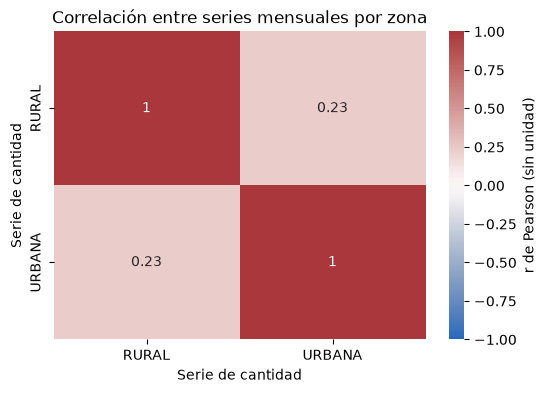

**Conclusión:** la correlación mensual urbana-rural es 0.232. Este valor no establece causalidad y puede cambiar si se corrige la cobertura temporal.

In [6]:
matriz=zona.pivot(index=['anio','mes'],columns='zona',values='cantidad')
corr=matriz.corr()
fig,ax=plt.subplots(figsize=(6,4)); sns.heatmap(corr,annot=True,vmin=-1,vmax=1,cmap='vlag',ax=ax,cbar_kws={'label':'r de Pearson (sin unidad)'})
ax.set(title='Correlación entre series mensuales por zona',xlabel='Serie de cantidad',ylabel='Serie de cantidad'); plt.show()
display(Markdown(f'**Conclusión:** la correlación mensual urbana-rural es {corr.loc["URBANA","RURAL"]:.3f}. Este valor no establece causalidad y puede cambiar si se corrige la cobertura temporal.'))

## Reflexión para el modelado posterior
CANTIDAD por fila está concentrada en 1 y tiene una cola derecha corta. La regla IQR degenera porque Q1=Q3=1; conservar los registros y revisar el origen es más razonable que filtrar automáticamente. Para modelos futuros se debe definir otra unidad de análisis (por ejemplo municipio-mes), confirmar cobertura y usar particiones temporales sin fuga de información.